In [1]:
# First physical cell verifies all bytes before teaching-code imports.
from pathlib import Path
import hashlib,json
BASE=next((p for p in [Path.cwd(),*Path.cwd().parents]
           if (p/'data_integrity.json').is_file() and (p/'experiment.py').is_file()),None)
if BASE is None:raise ValueError('Run within the complete ML051 folder')
EXPECTED={'data/protocol.json': '9198f86b5d490b6d83293f47774c0451899edd13b16a57e2273430e244e10e20', 'data/development.csv': 'de5a9a21a0fc87b346eac6867bd72351ae29276eedf50abce02aa4f905bda2a2', 'data/repeated_development.csv': 'a1cb11336f49825267a24d6880a6770720450db88ec435c44e53accae4c40736', 'data_integrity.json': '31c742436e41a09b05ddc5641e4c85dc7a5b5c3ce10d629fe7f2044a91166e2c', 'numeric.py': 'bef16b4d6ff94532107af3ffdcb43c35e4a4a3a5472b6ffd7e6f823aae3fb208', 'protocol.py': '3e554003109c60bed0118e0dd30c4c06edfb05a11f566762be87576a9132d6e4', 'models.py': '1f1bc2cd9db1102a84b5c4e66114e5d12149246528a56ecc0fa0683506a3e413', 'folds.py': '09149eb0dc86fa7c4d40306b2dad3676768587f3f0a044db100f33704d10360a', 'cross_validation.py': '191cd36e05334e3852650bf7e80fcee5699c15cef6fdcaa58c0bf58b10b25d0a', 'hand_example.py': 'd275c8ca0fad501983b27832b3936200624d48464455227d7d943b43a6d73f56', 'generate_data.py': '7967f20ea61cac775d983a3084cf9d495a9301e3f5c8054f9438b3ed7a1c7396', 'experiment.py': 'a0b2027632029c6a070d886ff230d0477df767307287e0bbf3ef5be4790a93fb', 'reference.py': '2d735607de766d0836927a3805d1921a7a72b84e2f334d950381947e5cca9da4', 'audit.py': '7cef91415952226e2cdb010fc7aed0195ad29d50ce097b7bc3651dce56e8783a', 'plots.py': '82a61867d377993fe8ba6c3fc0ca70a8cac33a3578b77cd1977eedb42d1bbff2', 'requirements.txt': '3fb2ffac7da882b9bf919c5b5517c61623d0f25ac090efefc5e11eb49d68fffb', 'environment.yml': '440243c3096feddc2b2fc6db9edf179fad936b27d814a553a8c5d66a50f5231d'}
for relative,wanted in EXPECTED.items():
    if hashlib.sha256((BASE/relative).read_bytes()).hexdigest()!=wanted:
        raise ValueError('Teaching contract changed: '+relative)
print('All',len(EXPECTED),'data/source/environment contracts verified.')

All 17 data/source/environment contracts verified.


# 第051讲 交叉验证与模型选择

先锁定候选和数据角色，再评价包含内层选参的完整过程。所有数据为合成，oracle只作诊断。

Protocol: {'kind': 'nested_cross_validation_legendre_v1', 'main_seed': 5105, 'repeated_seed': 5106, 'split_seed': 5107, 'test_seed': 5109, 'sample_count': 80, 'repetitions': 80, 'test_count': 4000, 'outer_folds': 5, 'inner_folds': 4, 'true_coefficients': [1.0, 0.8, -0.5, 0.3], 'noise_sd': 0.8, 'candidates': [{'degree': 0, 'penalty': 0.0}, {'degree': 1, 'penalty': 0.0}, {'degree': 1, 'penalty': 0.01}, {'degree': 1, 'penalty': 0.1}, {'degree': 1, 'penalty': 1.0}, {'degree': 3, 'penalty': 0.0}, {'degree': 3, 'penalty': 0.01}, {'degree': 3, 'penalty': 0.1}, {'degree': 3, 'penalty': 1.0}, {'degree': 5, 'penalty': 0.0}, {'degree': 5, 'penalty': 0.01}, {'degree': 5, 'penalty': 0.1}, {'degree': 5, 'penalty': 1.0}, {'degree': 9, 'penalty': 0.0}, {'degree': 9, 'penalty': 0.01}, {'degree': 9, 'penalty': 0.1}, {'degree': 9, 'penalty': 1.0}], 'tie_rule': 'first_candidate_in_declared_order', 'hand_training_x': [-2.0, -1.0, 1.0, 2.0], 'hand_training_y': [-1.0, -1.0, 1.0, 3.0], 'hand_test_x': [3.0, 4.

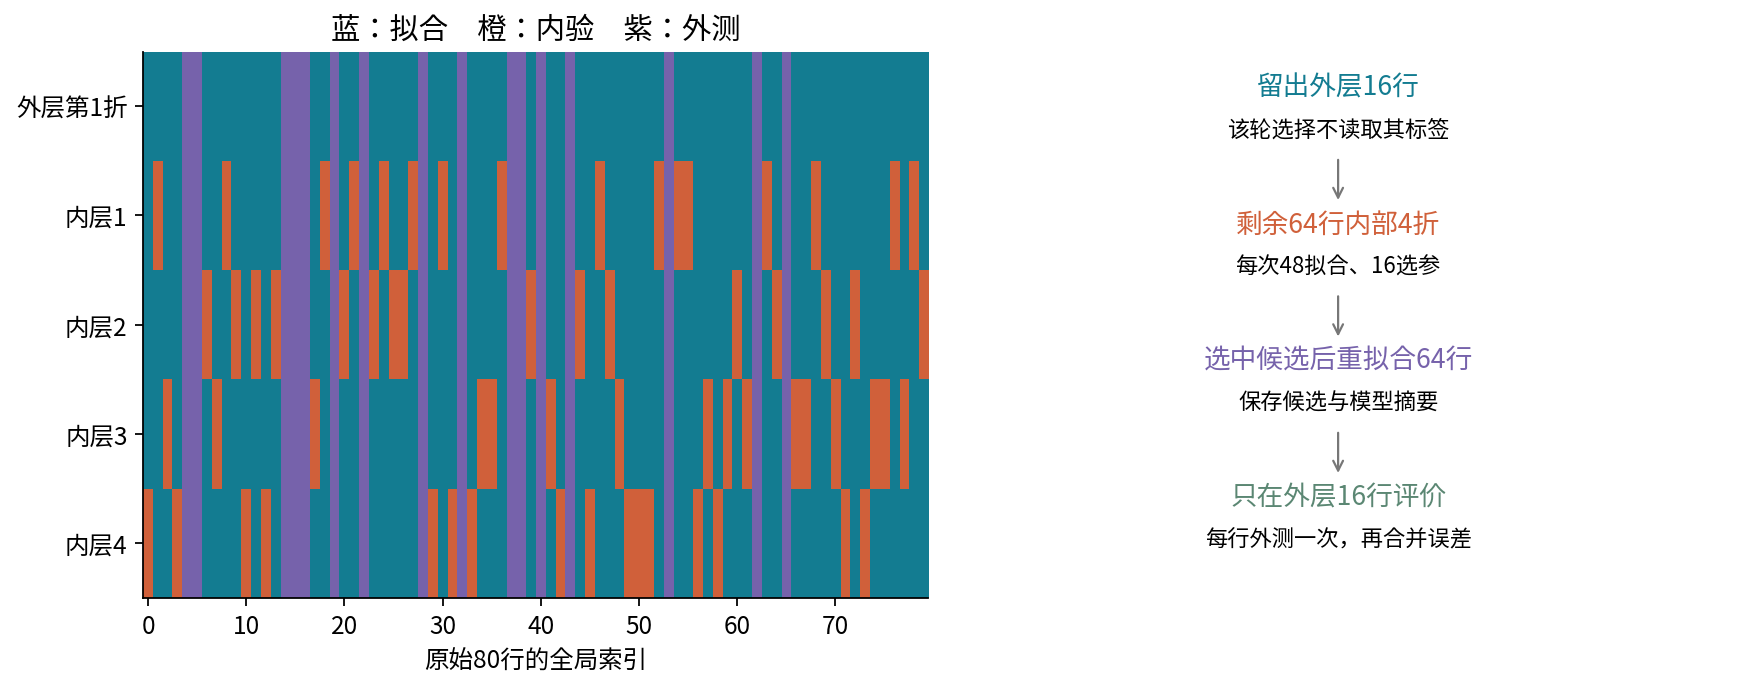

In [2]:
import os,sys,io,math
sys.path.insert(0,str(BASE))
os.environ.setdefault('MPLCONFIGDIR',str(BASE/'outputs/mpl'))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image,display
import experiment as e
import models,folds,cross_validation as cv,plots
from numeric import canonical_bytes,safe_write
main,repeated,cfg=e.load_inputs()
report=e.main_report(main,repeated,cfg)
def show(i):
    f=plots.figure(i,report);b=io.BytesIO()
    f.savefig(b,format='png',dpi=160,bbox_inches='tight')
    display(Image(data=b.getvalue(),format='png'));plt.close(f)
print('Protocol:',cfg)
print('Primary outer splits:',report['primary']['outer_splits'])
show(1)

## 四行纸笔内层选择
每个候选都接受两折评价，选出λ后用全部外层训练行重拟合。

PENALTY 0.0
Fit: {'sum_xy': 2.0, 'sum_x_squared': 2.0, 'n': 2, 'penalty': 0.0, 'denominator': 2.0, 'weight': 1.0} train [1, 2] validation [0, 3]
{'index': 0, 'x': -2.0, 'y': -1.0, 'prediction': -2.0, 'squared_loss': 1.0}
{'index': 3, 'x': 2.0, 'y': 3.0, 'prediction': 2.0, 'squared_loss': 1.0}
Fit: {'sum_xy': 8.0, 'sum_x_squared': 8.0, 'n': 2, 'penalty': 0.0, 'denominator': 8.0, 'weight': 1.0} train [0, 3] validation [1, 2]
{'index': 1, 'x': -1.0, 'y': -1.0, 'prediction': -1.0, 'squared_loss': 0.0}
{'index': 2, 'x': 1.0, 'y': 1.0, 'prediction': 1.0, 'squared_loss': 0.0}
Pooled CV MSE: 0.5
PENALTY 1.0
Fit: {'sum_xy': 2.0, 'sum_x_squared': 2.0, 'n': 2, 'penalty': 1.0, 'denominator': 4.0, 'weight': 0.5} train [1, 2] validation [0, 3]
{'index': 0, 'x': -2.0, 'y': -1.0, 'prediction': -1.0, 'squared_loss': 0.0}
{'index': 3, 'x': 2.0, 'y': 3.0, 'prediction': 1.0, 'squared_loss': 4.0}
Fit: {'sum_xy': 8.0, 'sum_x_squared': 8.0, 'n': 2, 'penalty': 1.0, 'denominator': 10.0, 'weight': 0.8} train [0

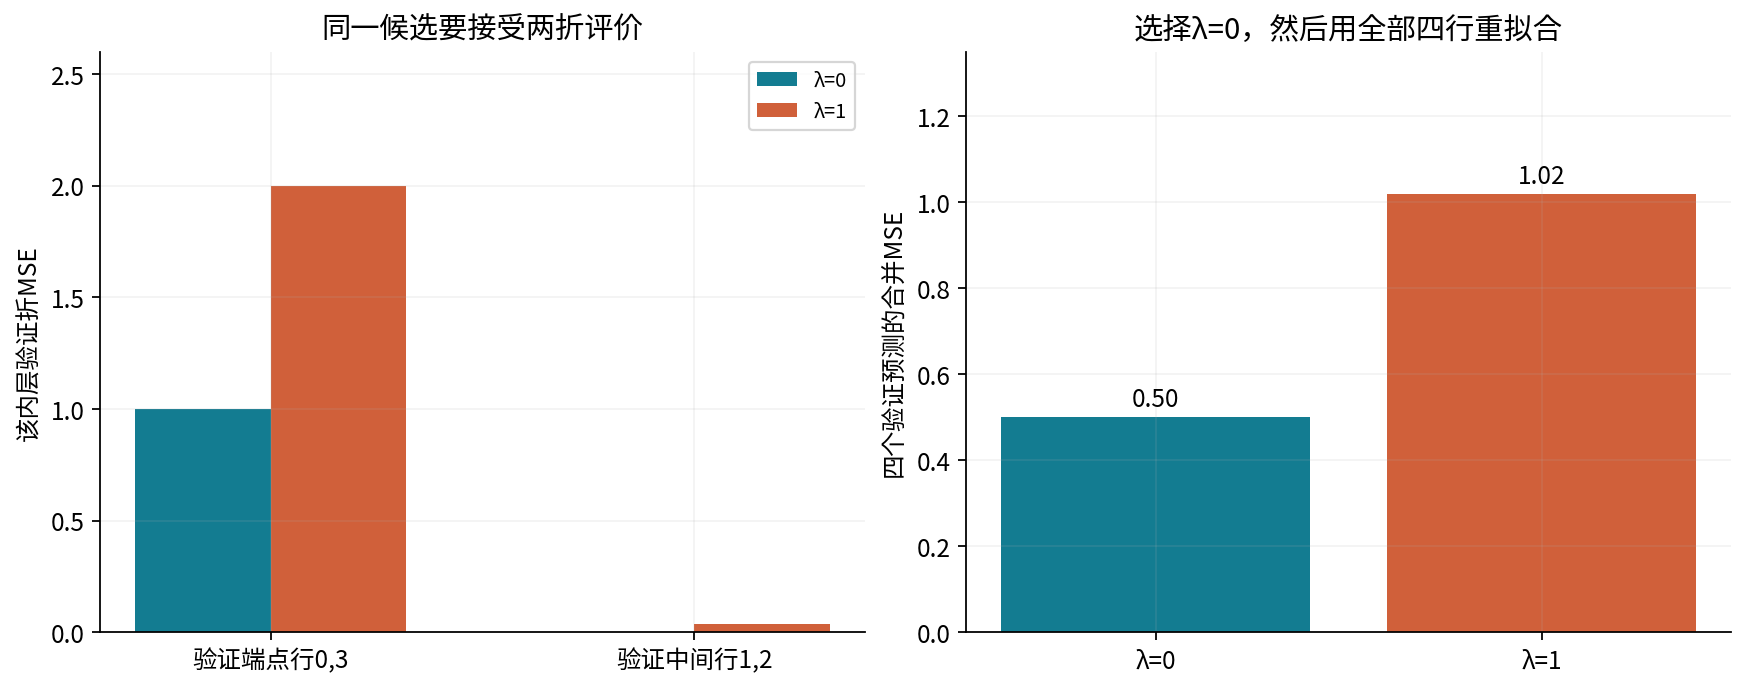

In [3]:
h=report['hand']
for candidate in h['candidates']:
    print('PENALTY',candidate['penalty'])
    for inner in candidate['folds']:
        print('Fit:',inner['fit'],'train',inner['training_indices'],'validation',inner['validation_indices'])
        for row in inner['validation_rows']:print(row)
    print('Pooled CV MSE:',candidate['pooled_CV_MSE'])
print('Selected penalty:',h['selected_penalty'])
print('Refit all four:',h['outer_training_refit'])
print('Outer test rows and MSE:',h['outer_test_rows'],h['outer_test_MSE'])
show(2)

STAGE 0 weight 0.0
{"half_squared_loss": 0.5, "local_dloss_dprediction": 1.0, "local_dprediction_dw": -2.0, "mean_data_loss_contribution": 0.125, "mean_gradient_contribution": -0.5, "prediction": -0.0, "residual": 1.0, "row": 0, "x": -2.0, "y": -1.0}
{"half_squared_loss": 0.5, "local_dloss_dprediction": 1.0, "local_dprediction_dw": -1.0, "mean_data_loss_contribution": 0.125, "mean_gradient_contribution": -0.25, "prediction": -0.0, "residual": 1.0, "row": 1, "x": -1.0, "y": -1.0}
{"half_squared_loss": 0.5, "local_dloss_dprediction": -1.0, "local_dprediction_dw": 1.0, "mean_data_loss_contribution": 0.125, "mean_gradient_contribution": -0.25, "prediction": 0.0, "residual": -1.0, "row": 2, "x": 1.0, "y": 1.0}
{"half_squared_loss": 4.5, "local_dloss_dprediction": -3.0, "local_dprediction_dw": 2.0, "mean_data_loss_contribution": 1.125, "mean_gradient_contribution": -1.5, "prediction": 0.0, "residual": -3.0, "row": 3, "x": 2.0, "y": 3.0}
{'weight': 0.0, 'data_half_MSE': 1.5, 'penalty_value': 

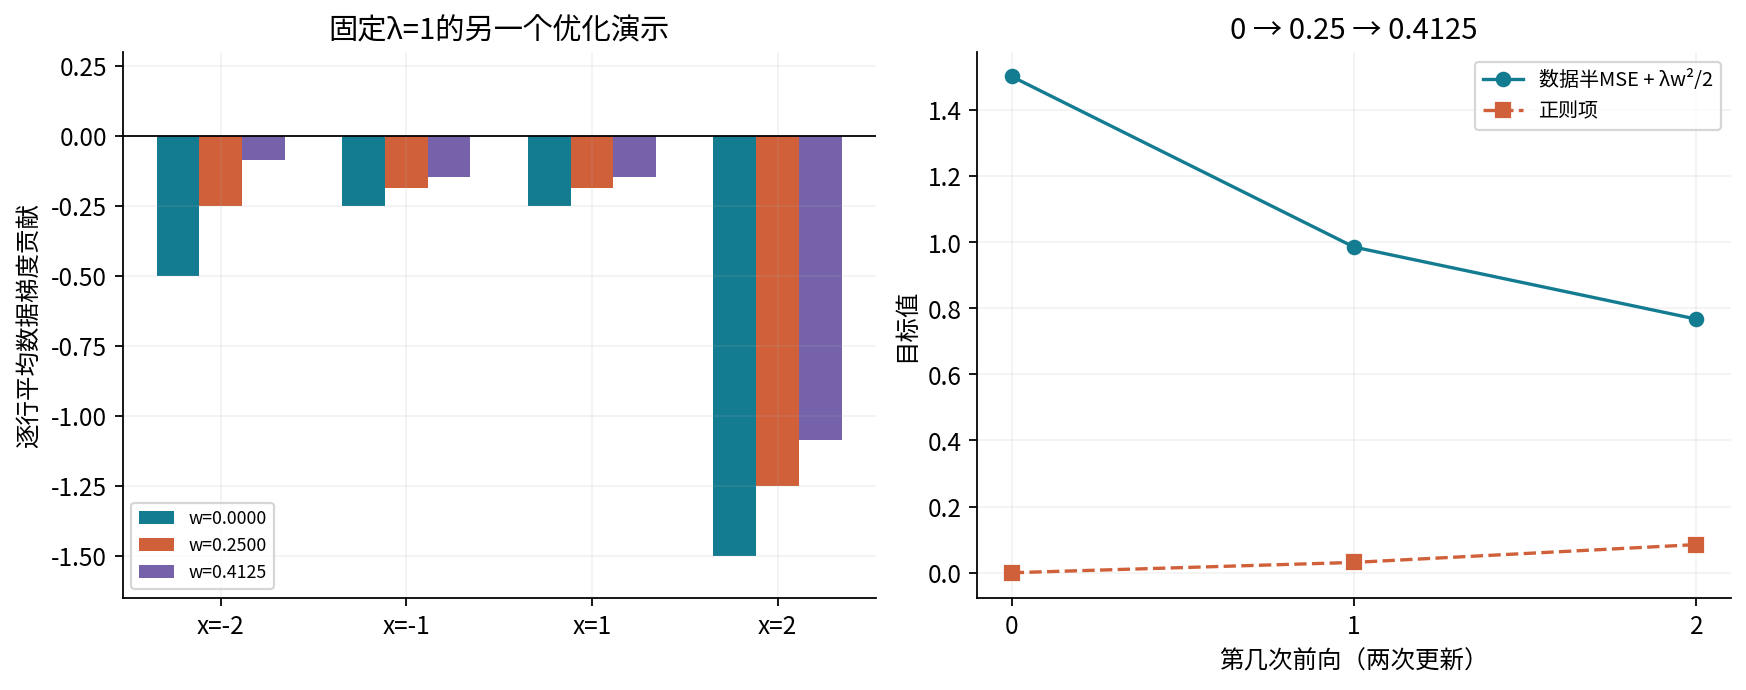

In [4]:
for state in h['gradient_trace']:
    print('STAGE',state['stage'],'weight',state['weight'])
    for row in state['rows']:print(json.dumps(row,sort_keys=True))
    print({k:v for k,v in state.items() if k!='rows'})
    if state['stage']<2:print('Next synchronous weight:',state['weight']-cfg['hand_learning_rate']*state['total_gradient'])
print('Fixed-trace closed-form optimum:',h['trace_closed_form_optimum'])
show(3)

## 固定基函数与惩罚缩放
Legendre基不是从全数据fit得到的。λ与sklearn alpha需按训练行数换算。

In [5]:
print('All17 candidates:',cfg['candidates'])
for n in [48,64,80]:print('n,lambda,sklearn alpha:',n,.01,n*.01)
from reference import ReferenceRidge
fit=models.fit(main['x'],main['y'],{'degree':3,'penalty':.01})
reference=ReferenceRidge(degree=3,penalty=.01).fit(main['x'][:,None],main['y'])
print('Augmented least-squares coefficients:',fit['coefficients'])
print('Actual sklearn Ridge coefficients:',reference.coefficients_.tolist())
if not np.allclose(fit['coefficients'],reference.coefficients_,rtol=1e-10,atol=1e-12):raise RuntimeError('Ridge objective mismatch')
print('Unequal fold example pooled versus unweighted:',(3*0+2*1+2*4)/7,(0+1+4)/3)

All17 candidates: [{'degree': 0, 'penalty': 0.0}, {'degree': 1, 'penalty': 0.0}, {'degree': 1, 'penalty': 0.01}, {'degree': 1, 'penalty': 0.1}, {'degree': 1, 'penalty': 1.0}, {'degree': 3, 'penalty': 0.0}, {'degree': 3, 'penalty': 0.01}, {'degree': 3, 'penalty': 0.1}, {'degree': 3, 'penalty': 1.0}, {'degree': 5, 'penalty': 0.0}, {'degree': 5, 'penalty': 0.01}, {'degree': 5, 'penalty': 0.1}, {'degree': 5, 'penalty': 1.0}, {'degree': 9, 'penalty': 0.0}, {'degree': 9, 'penalty': 0.01}, {'degree': 9, 'penalty': 0.1}, {'degree': 9, 'penalty': 1.0}]
n,lambda,sklearn alpha: 48 0.01 0.48
n,lambda,sklearn alpha: 64 0.01 0.64
n,lambda,sklearn alpha: 80 0.01 0.8
Augmented least-squares coefficients: [0.9529797211470827, 0.8531524308101911, -0.3384819387584848, 0.11067457469399171]
Actual sklearn Ridge coefficients: [0.9529797211470826, 0.8531524308101913, -0.3384819387584849, 0.11067457469399163]
Unequal fold example pooled versus unweighted: 1.4285714285714286 1.6666666666666667


OUTER FOLD 0
Outer train/validation: [0, 1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 17, 18, 20, 21, 23, 24, 25, 26, 27, 29, 30, 31, 33, 34, 35, 36, 39, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 63, 64, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79] [4, 5, 14, 15, 16, 19, 22, 28, 32, 37, 38, 40, 43, 53, 62, 65]
Inner global train/validation: [0, 2, 3, 6, 7, 9, 10, 11, 12, 13, 17, 20, 23, 25, 26, 29, 31, 33, 34, 35, 39, 41, 42, 44, 45, 47, 48, 49, 50, 51, 56, 57, 58, 59, 60, 61, 64, 66, 67, 69, 70, 71, 72, 73, 74, 75, 77, 79] [1, 8, 18, 21, 24, 27, 30, 36, 46, 52, 54, 55, 63, 68, 76, 78]
All candidate MSE: [1.2591335864316353, 0.6436719679711209, 0.6548971757230517, 0.7413816629802413, 1.0511885622573836, 0.6704523362352823, 0.6785843054163352, 0.7501427775088794, 1.0477545870850677, 0.6680845075783016, 0.6763206288561185, 0.7491108147727791, 1.047648480975954, 0.6410890406209032, 0.6446819852714826, 0.7303610094881574, 1.0433144913963055]
Inner globa

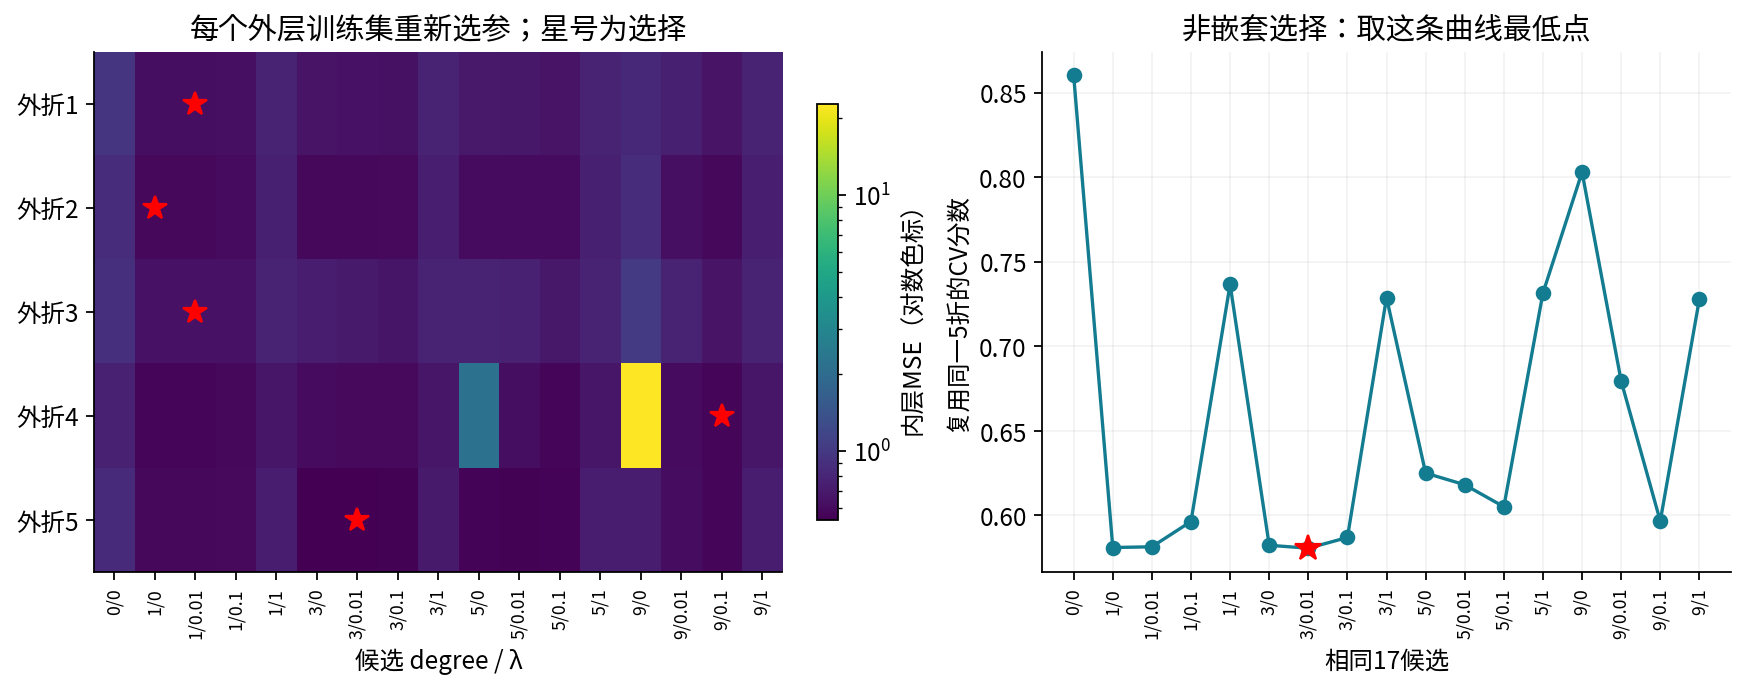

In [6]:
primary=report['primary']
for outer in primary['nested']['folds']:
    print('OUTER FOLD',outer['outer_fold'])
    print('Outer train/validation:',outer['training_indices'],outer['validation_indices'])
    s=outer['choice']['selection']
    for inner in s['folds']:
        print('Inner global train/validation:',inner['training_indices_global'],inner['validation_indices_global'])
        print('All candidate MSE:',inner['candidate_MSE'])
    print('Pooled scores and selection:',s['candidate_scores'],s['selected_index'],s['selected_candidate'])
    print('Choice hash before outer score:',outer['choice_sha256'])
print('Flat reused selection:',primary['flat']['selection']['selected_candidate'])
show(4)

Outer fold: 0 predictions: [0.7789834560166136, 1.1240044614350777, 0.8210914500508, 0.30657353206811366, 1.6878464853798376, 1.691184750842953, 0.5336154465809541, 0.07349741656071818, 0.7470419777516784, 1.5883422822846005, 0.876546815846497, 0.26193377837008003, 0.3851924385868192, 1.8583892645094273, 1.089855752512416, 1.0361111181780482]
Squared errors: [0.37237386455186433, 0.5573990911170531, 1.2833051349754612, 0.01840632920962891, 0.18650287502286647, 0.03159708779825572, 0.6729970082738179, 0.39390302740783995, 0.1298926294421189, 1.4522622014754927, 0.730439590125757, 1.9886352223012034, 0.46971130211187284, 1.2377809847789438, 0.2538186064158277, 0.20032989313092667]
MSE and same-model oracle: 0.6237096780086832 {'total_MSE': 0.7133978583595746, 'noise_variance': 0.6400000000000001, 'integrated_squared_error_of_this_fitted_function': 0.0733978583595745, 'Legendre_component_terms': [0.0007702040831311643, 0.009770511419300477, 0.05, 0.012857142857142857], 'scope': 'condition

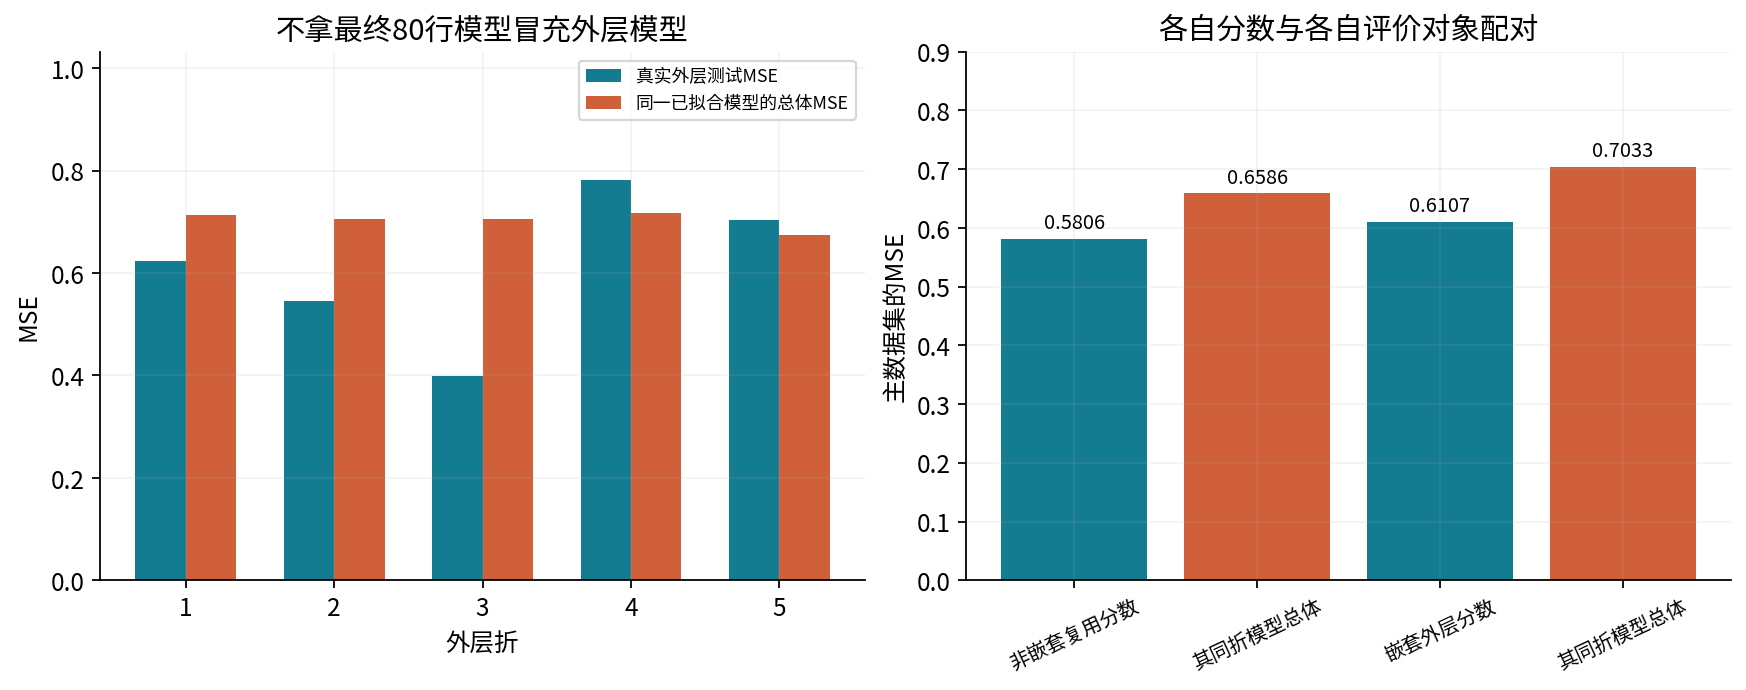

In [7]:
for outer in primary['nested']['folds']:
    print('Outer fold:',outer['outer_fold'],'predictions:',outer['validation_predictions'])
    print('Squared errors:',outer['validation_squared_errors'])
    print('MSE and same-model oracle:',outer['validation_MSE'],outer['oracle_risk_same_fitted_model'])
print('Flat CV/oracle:',primary['flat']['minimum_reused_CV_MSE'],primary['flat']['mean_oracle_risk_same_selected_fold_models'])
print('Nested CV/oracle:',primary['nested']['pooled_outer_MSE'],primary['nested']['mean_oracle_risk_same_outer_models'])
show(5)

## 80个独立数据集 不把五折当独立实验
完整索引与候选分数在report中保存，下面打印每份数据的关键配对结果。

0 flat CV/oracle/gap 0.6209990378721687 0.7668365485403481 0.1458375106681794 nested CV/oracle/gap 0.6294088140475758 0.759748321233792 0.13033950718621623
1 flat CV/oracle/gap 0.631381149950525 0.7514507528212343 0.12006960287070934 nested CV/oracle/gap 0.6447686703167987 0.7043818482976378 0.059613177980839094
2 flat CV/oracle/gap 0.8980097503910601 0.7637786281880947 -0.1342311222029654 nested CV/oracle/gap 1.0249271290076316 0.7123039081065964 -0.3126232209010352
3 flat CV/oracle/gap 0.6435796771270118 0.6596620781734511 0.01608240104643932 nested CV/oracle/gap 0.7025795176502727 0.6945739502868239 -0.008005567363448818
4 flat CV/oracle/gap 0.5736330748050198 0.6807672529009274 0.10713417809590764 nested CV/oracle/gap 0.6241042840774512 0.7368869484083208 0.11278266433086959
5 flat CV/oracle/gap 0.7130072349640924 0.7010959514405852 -0.011911283523507121 nested CV/oracle/gap 0.7251024925658099 0.7700153693090265 0.044912876743216534
6 flat CV/oracle/gap 0.5901270934733586 0.6505918

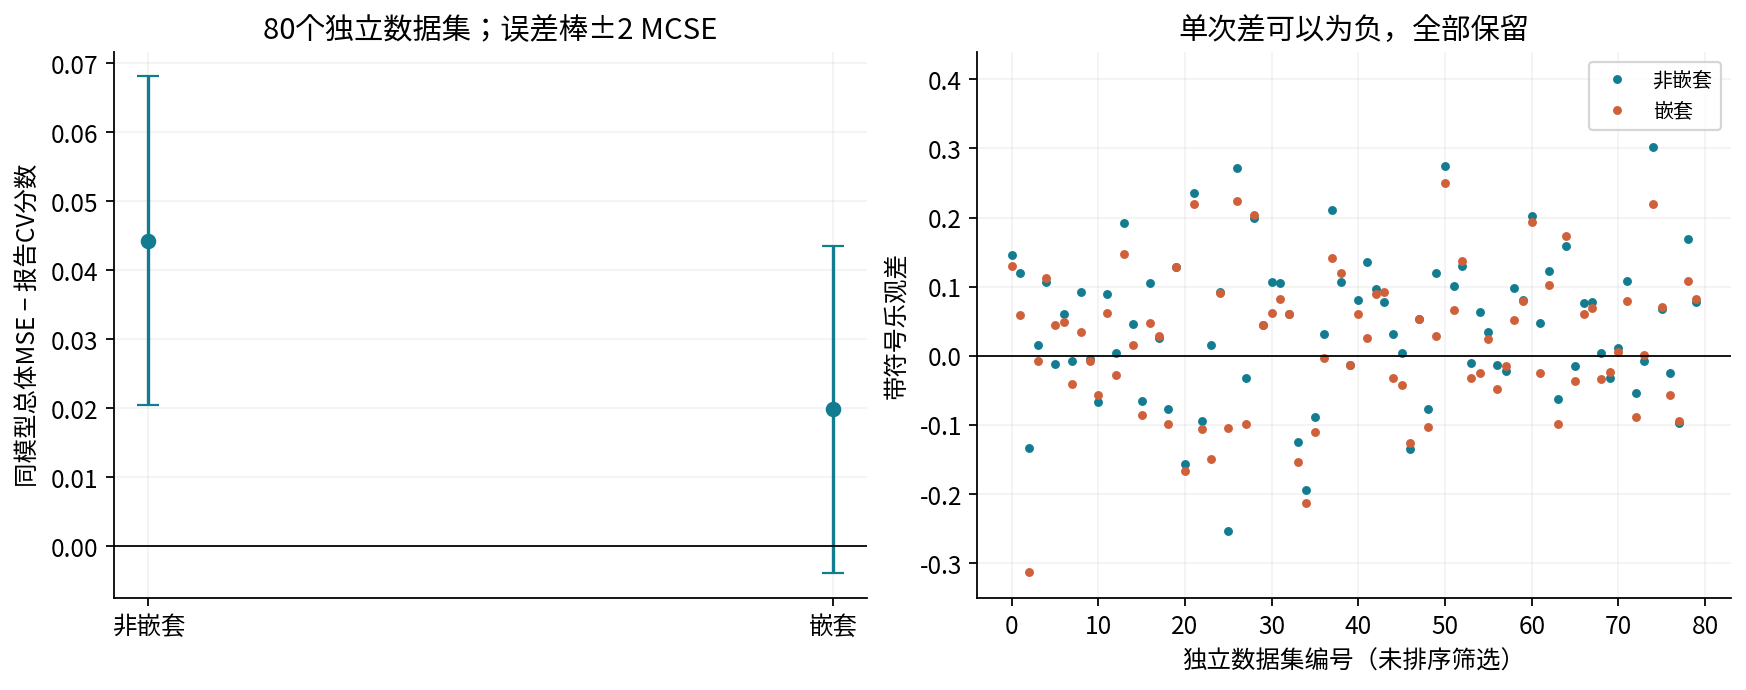

In [8]:
for row in report['repeated']:
    result=row['result'];print(row['repetition'],
       'flat CV/oracle/gap',result['flat']['minimum_reused_CV_MSE'],result['flat']['mean_oracle_risk_same_selected_fold_models'],result['flat']['oracle_minus_CV'],
       'nested CV/oracle/gap',result['nested']['pooled_outer_MSE'],result['nested']['mean_oracle_risk_same_outer_models'],result['nested']['oracle_minus_CV'])
print('Summary:',json.dumps(report['repeated_summary'],sort_keys=True))
show(6)

Flat score lower/equal/higher: 73 5 2
Final selected indices: [6, 14, 10, 6, 6, 6, 6, 6, 2, 10, 6, 15, 6, 10, 6, 10, 10, 7, 6, 6, 6, 6, 6, 10, 15, 6, 14, 6, 7, 6, 11, 7, 6, 15, 6, 6, 11, 1, 6, 6, 14, 14, 6, 6, 14, 10, 7, 6, 15, 14, 11, 6, 6, 2, 2, 6, 10, 7, 15, 5, 10, 15, 6, 1, 6, 11, 5, 6, 15, 6, 6, 2, 6, 6, 14, 6, 6, 6, 14, 6]
Negative optimism counts: 27 34


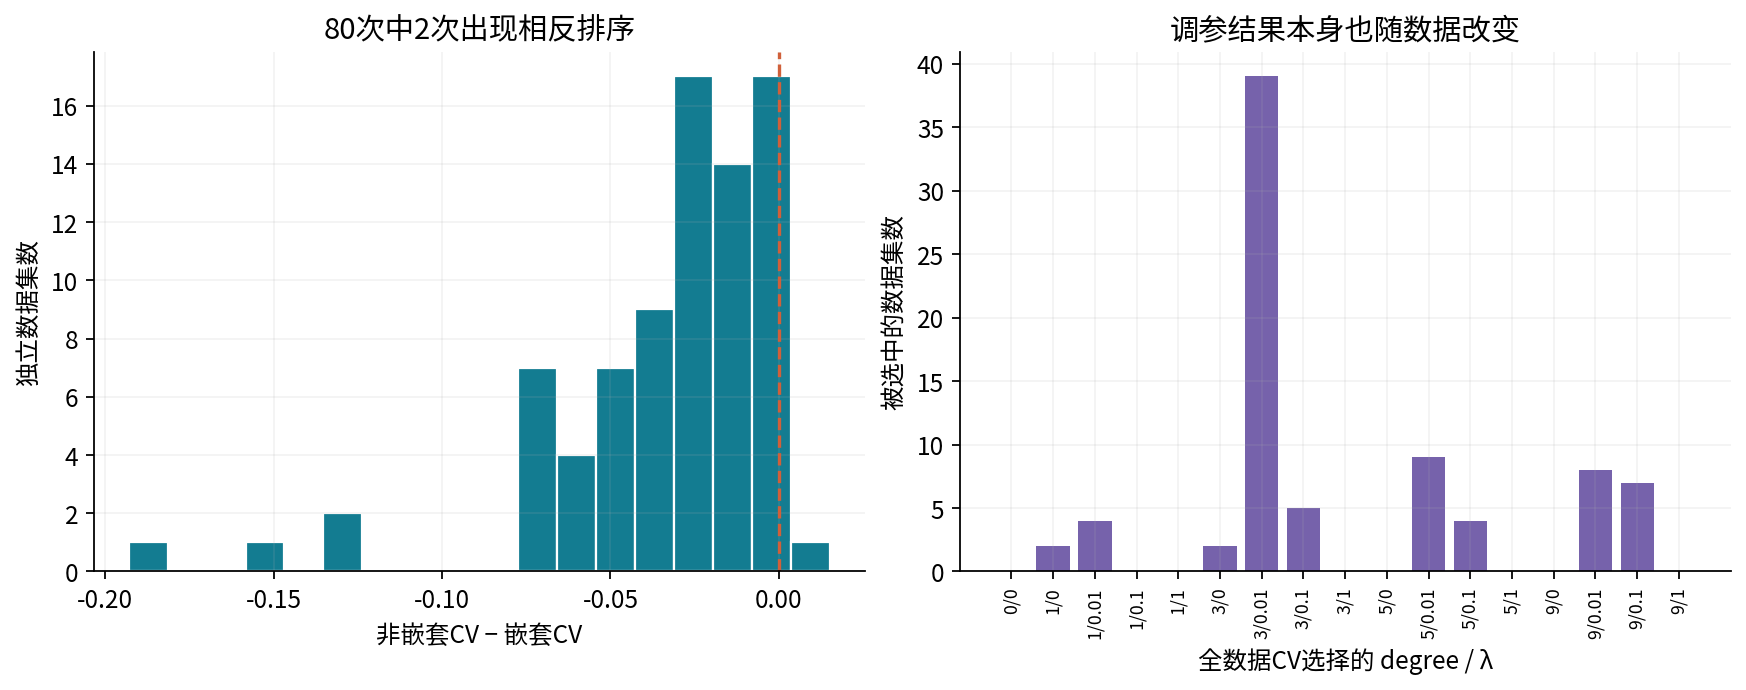

In [9]:
differences=np.array([row['result']['flat']['minimum_reused_CV_MSE']-row['result']['nested']['pooled_outer_MSE'] for row in report['repeated']])
print('Flat score lower/equal/higher:',int((differences<0).sum()),int((differences==0).sum()),int((differences>0).sum()))
print('Final selected indices:',[row['result']['final_choice']['selected_index'] for row in report['repeated']])
print('Negative optimism counts:',report['repeated_summary']['flat_optimism']['negative_count'],report['repeated_summary']['nested_optimism']['negative_count'])
show(7)

Labels: [0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1] groups: [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3]
SPLITTER KFold
{"training_groups": [0, 1, 2, 3], "training_indices": [0, 1, 2, 3, 6, 7, 9, 10], "training_max_time": 10, "training_positive_count": 2, "validation_groups": [1, 2, 3], "validation_indices": [4, 5, 8, 11], "validation_min_time": 4, "validation_positive_count": 4}
{"training_groups": [1, 2, 3], "training_indices": [3, 4, 5, 6, 8, 9, 10, 11], "training_max_time": 11, "training_positive_count": 5, "validation_groups": [0, 2], "validation_indices": [0, 1, 2, 7], "validation_min_time": 0, "validation_positive_count": 1}
{"training_groups": [0, 1, 2, 3], "training_indices": [0, 1, 2, 4, 5, 7, 8, 11], "training_max_time": 11, "training_positive_count": 5, "validation_groups": [1, 2, 3], "validation_indices": [3, 6, 9, 10], "validation_min_time": 3, "validation_positive_count": 1}
SPLITTER StratifiedKFold
{"training_groups": [0, 1, 2, 3], "training_indices": [0, 2, 3, 4, 6, 8, 9, 10], "train

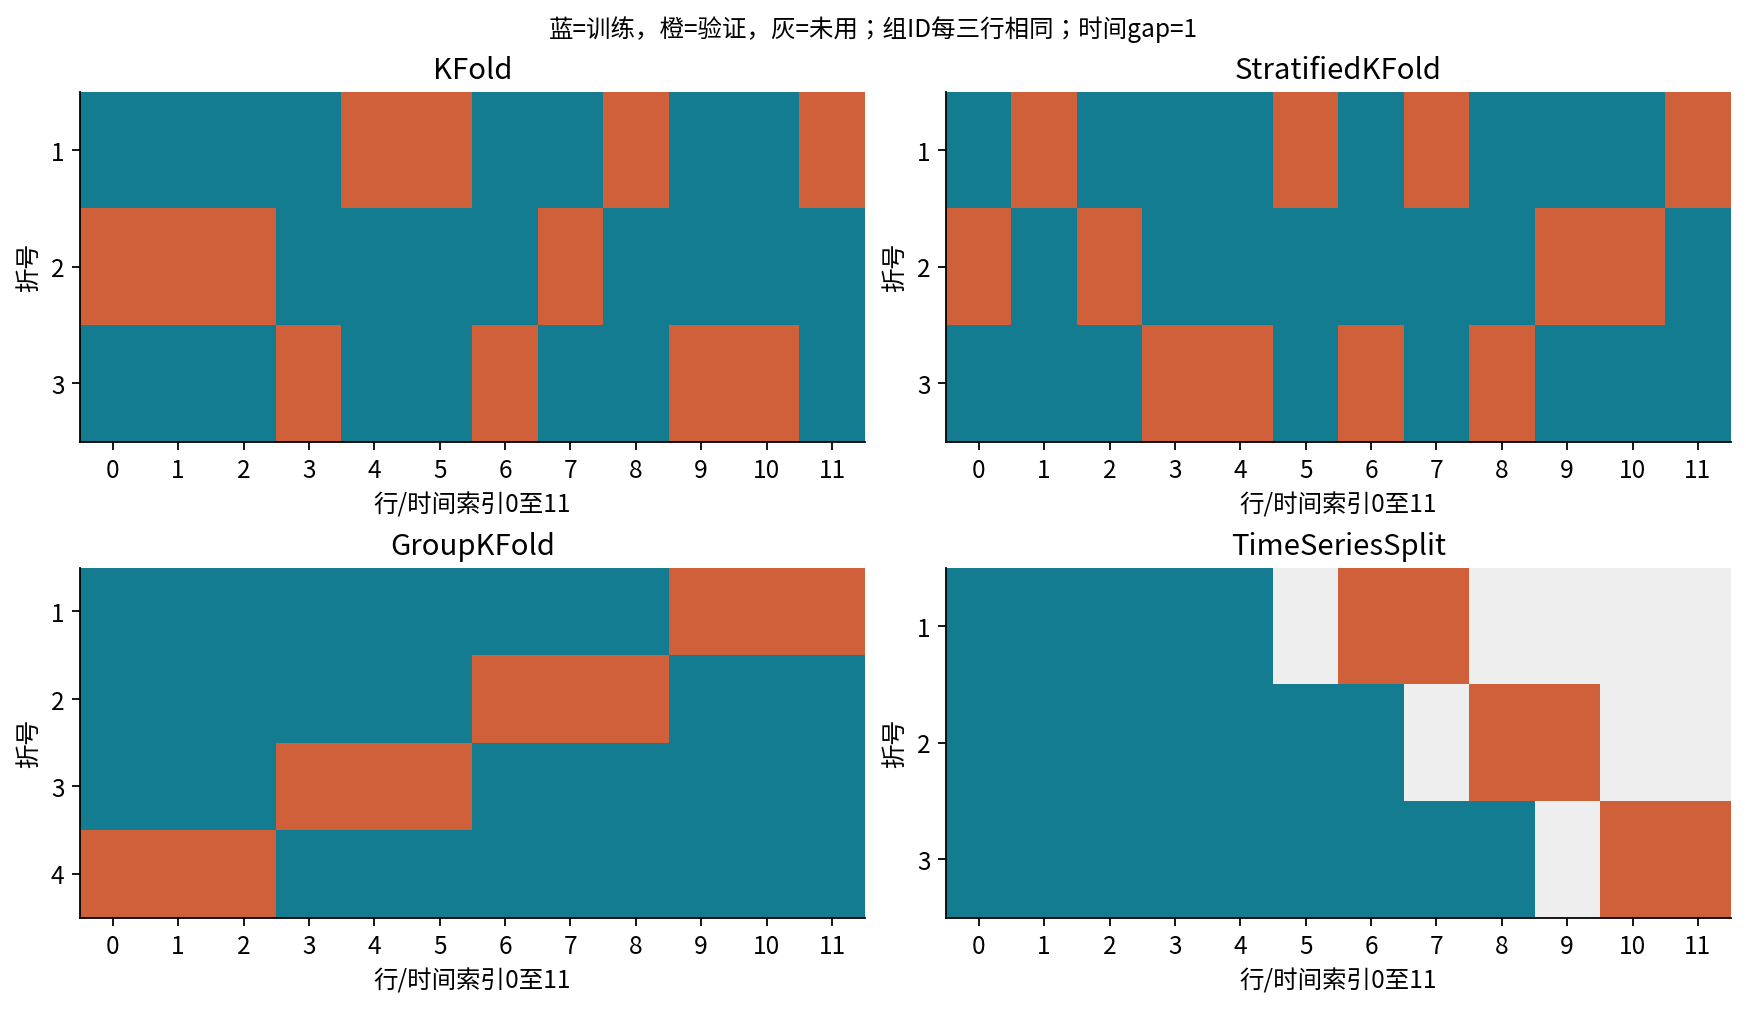

In [10]:
demo=report['splitter_demo']
print('Labels:',demo['binary_labels'],'groups:',demo['groups'])
for name,rows in demo['splitters'].items():
    print('SPLITTER',name)
    for row in rows:print(json.dumps(row,sort_keys=True))
print('Scope:',demo['scope'])
show(8)

Training-row overlap fraction, NOT correlation: [[1.   0.75 0.75 0.75 0.75]
 [0.75 1.   0.75 0.75 0.75]
 [0.75 0.75 1.   0.75 0.75]
 [0.75 0.75 0.75 1.   0.75]
 [0.75 0.75 0.75 0.75 1.  ]]
Fold MSEs: [0.6237096780086832, 0.545137233196553, 0.39898754760833044, 0.7823008828194727, 0.7034632746017628]
No independent-fold t test is performed.


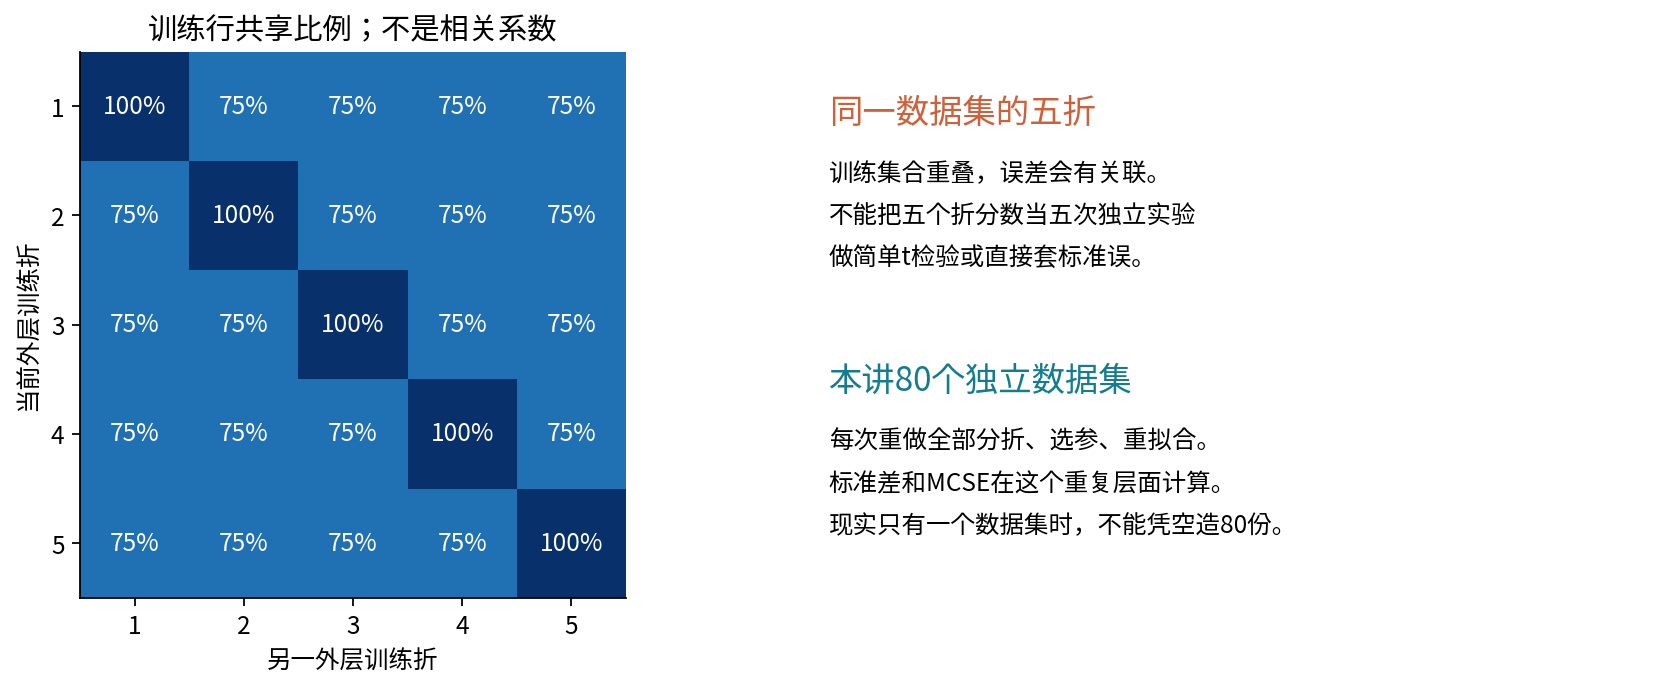

In [11]:
training=[set(row['training_indices']) for row in primary['outer_splits']]
overlap=np.array([[len(a&b)/len(a) for b in training] for a in training])
print('Training-row overlap fraction, NOT correlation:',overlap)
print('Fold MSEs:',[row['validation_MSE'] for row in primary['nested']['folds']])
print('No independent-fold t test is performed.')
show(9)

## 最终80行模型与独立4000行测试
不从五个外折模型挑最好者，最终模型按预定流程在全部开发数据选择与拟合。

Final choice: {'selected_index': 6, 'selected_candidate': {'degree': 3, 'penalty': 0.01}, 'candidate_CV_scores': [0.8601878306919302, 0.5810227491515874, 0.5814426709202316, 0.5964015958389529, 0.7365988920091886, 0.582349056634467, 0.5806134807655501, 0.5869529828965888, 0.7287389029607122, 0.6250308807091588, 0.6181219385014397, 0.6051197752013503, 0.7314628758899533, 0.8029271601911484, 0.679429294239607, 0.5966484239427542, 0.7278585135668149], 'development_count': 80, 'model': {'candidate': {'degree': 3, 'penalty': 0.01}, 'n_training': 80, 'coefficients': [0.9529797211470827, 0.8531524308101911, -0.3384819387584848, 0.11067457469399171], 'rank': 4, 'condition_number': 2.7593648871551557, 'training_MSE': 0.5308234492310564, 'mean_half_loss_plus_penalty': 0.2696851643882619, 'penalty_convention': 'mean half-SSE + lambda/2 * sum(non-intercept Legendre coefficients squared); sklearn alpha=n_train*lambda'}}
Final choice SHA256: 630907edbbd7a18883ef8fc897a9ad5df887255161db02ac14da95fefb

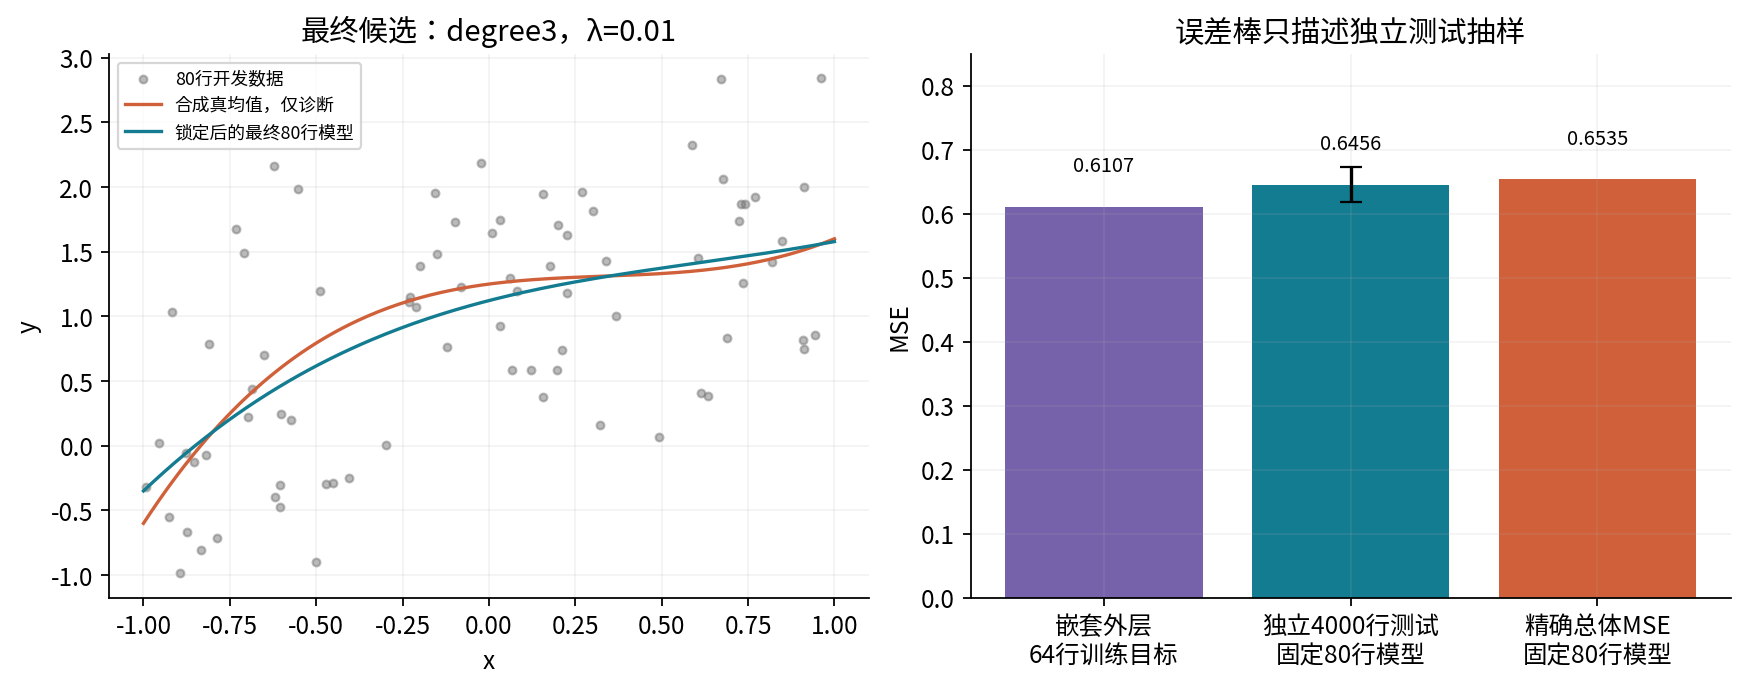

In [12]:
print('Final choice:',primary['final_choice'])
print('Final choice SHA256:',primary['final_choice_sha256'])
test=report['final_test']
print('Choice recorded before test:',test['choice_sha256_before_test'])
print('Final test MSE/conditional SE:',test['MSE'],test['conditional_test_mean_loss_SE'])
print('Same final model oracle:',primary['final_model_oracle_risk'])
for i in range(5):print('Test row',test['test_data']['id'][i],test['test_data']['x'][i],test['test_data']['y'][i],test['predictions'][i],test['squared_losses'][i])
show(10)

## 独立数学与库参照
Fraction链、不同基函数的QR、实际Ridge/GridSearchCV和独立求积；信息流变换与普通输入检查。

In [13]:
import audit
checks=audit.audit(report)
print(json.dumps(checks,ensure_ascii=False,sort_keys=True))
scientific_hash=hashlib.sha256(canonical_bytes(report)).hexdigest()
if checks['core_sha256']!=scientific_hash:raise RuntimeError('Notebook report and audit differ')
safe_write(BASE/'outputs/notebook-result.json',report)
print('Saved full scientific report. SHA256:',scientific_hash)

{"actual_GridSearchCV_primary_five_inner_and_final_checked": true, "actual_sklearn_selected_models_checked": true, "all_81_datasets_inner_and_outer_grid_scores_checked": true, "core_sha256": "716ce52cd6bfd131da7150444e8750effbd63fa4490e2d40dc5acfc7a073da73", "data_CSV_byte_reproduced": true, "guards": {"JSON_preservation_and_alias_checks": true, "ordinary_invalid_input_and_precompute_last_field_checks": true, "unequal_fold_weighting_checked": true}, "hand": {"Fraction_inner_scores": ["1/2", "51/50"], "three_forward_stages_all_rows_checked": true, "two_synchronous_updates_checked": true}, "independence": {"final_test_not_passed_to_selection_API": true, "oracle_change_leaves_all_choices_identical": true, "outer_label_mutation_leaves_its_choice_byte_identical": true}, "independent_all_grid_SSE_max_absolute_error": 2.142769517377019e-09, "independent_all_grid_SSE_max_scaled_error": 1.1985751391458695e-13, "selected_predictor_population_risks_checked_by_quadrature": true, "splitter_group_ti

Saved full scientific report. SHA256: 716ce52cd6bfd131da7150444e8750effbd63fa4490e2d40dc5acfc7a073da73
